# 5004 HW3

Name: LAN, Tianwei  
Student ID: 21230969  
Email: tlanaa@connect.ust.hk

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

sunspots_path = 'sunspots.txt'
dow_path = 'dow.txt'
dow2_path = 'dow2.txt'
blur_path = 'blur.txt'

print('Setup completed.')

Setup completed.


## 1) Detecting Periodicity (Sunspots)

Read the monthly sunspot data, plot it in time, estimate the cycle length from the time-domain signal, and then confirm the period via the Fourier power spectrum.

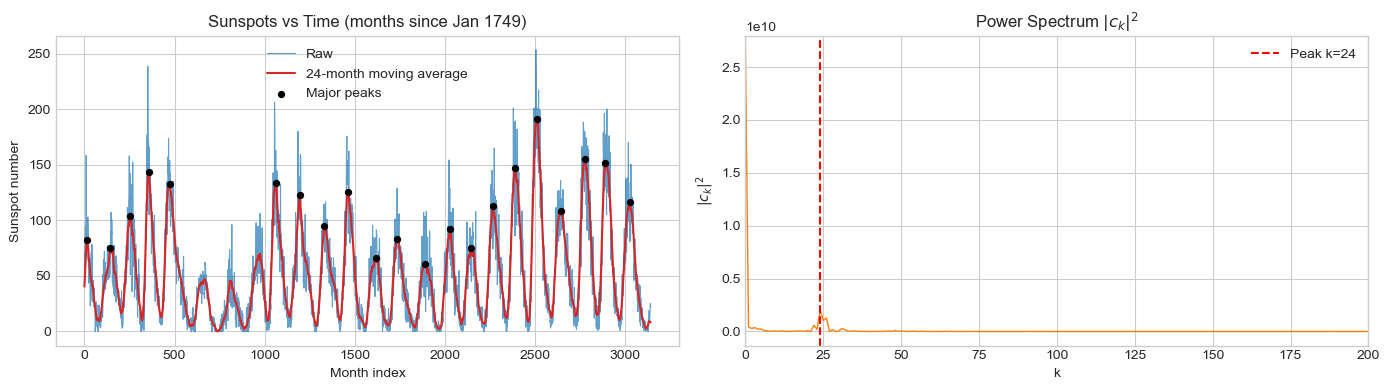

Time-domain cycle estimate (smoothed major-peak spacing): 129.50 months
Peak Fourier mode: k = 24
Period from Fourier peak (N/k): 130.96 months


In [2]:
# Q1(a)(b)(c): Sunspots periodicity analysis
sun_data = np.loadtxt(sunspots_path)
months = sun_data[:, 0]
sunspots = sun_data[:, 1]
N_sun = len(sunspots)

# Time-domain cycle estimate: smooth first, then detect major peaks
window = 24
kernel = np.ones(window) / window
sunspots_smooth = np.convolve(sunspots, kernel, mode='same')

is_peak = (sunspots_smooth[1:-1] > sunspots_smooth[:-2]) & (sunspots_smooth[1:-1] >= sunspots_smooth[2:])
peak_candidates = np.where(is_peak)[0] + 1
peak_candidates = peak_candidates[sunspots_smooth[peak_candidates] > np.percentile(sunspots_smooth, 60)]

min_distance = 80
major_peaks = []
for idx in peak_candidates:
    if not major_peaks:
        major_peaks.append(idx)
    elif idx - major_peaks[-1] >= min_distance:
        major_peaks.append(idx)
    elif sunspots_smooth[idx] > sunspots_smooth[major_peaks[-1]]:
        major_peaks[-1] = idx

major_peaks = np.array(major_peaks, dtype=int)
if len(major_peaks) >= 2:
    visual_period_est = np.median(np.diff(months[major_peaks]))
else:
    visual_period_est = np.nan

# Fourier transform and power spectrum
a_k = np.fft.rfft(sunspots)
k_vals = np.arange(len(a_k))
power = np.abs(a_k) ** 2

# Dominant nonzero Fourier mode
k_peak = np.argmax(power[1:]) + 1
period_fft = N_sun / k_peak

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(months, sunspots, color='tab:blue', linewidth=0.8, alpha=0.7, label='Raw')
axes[0].plot(months, sunspots_smooth, color='tab:red', linewidth=1.5, label='24-month moving average')
if len(major_peaks) > 0:
    axes[0].scatter(months[major_peaks], sunspots_smooth[major_peaks], color='black', s=18, zorder=3, label='Major peaks')
axes[0].set_title('Sunspots vs Time (months since Jan 1749)')
axes[0].set_xlabel('Month index')
axes[0].set_ylabel('Sunspot number')
axes[0].legend()

axes[1].plot(k_vals, power, color='tab:orange', linewidth=1)
axes[1].set_xlim(0, 200)
axes[1].set_title(r'Power Spectrum $|c_k|^2$')
axes[1].set_xlabel('k')
axes[1].set_ylabel(r'$|c_k|^2$')
axes[1].axvline(k_peak, color='red', linestyle='--', label=f'Peak k={k_peak}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Time-domain cycle estimate (smoothed major-peak spacing): {visual_period_est:.2f} months')
print(f'Peak Fourier mode: k = {k_peak}')
print(f'Period from Fourier peak (N/k): {period_fft:.2f} months')

## 2) Fourier Filtering and Smoothing (Dow Data)

Smooth the Dow signals by keeping only low-frequency coefficients:
- First with DFT for `dow.txt` (10% and 2%).
- Then for `dow2.txt`, compare DFT 2% vs DCT 2% to show the endpoint improvement of cosine transforms.

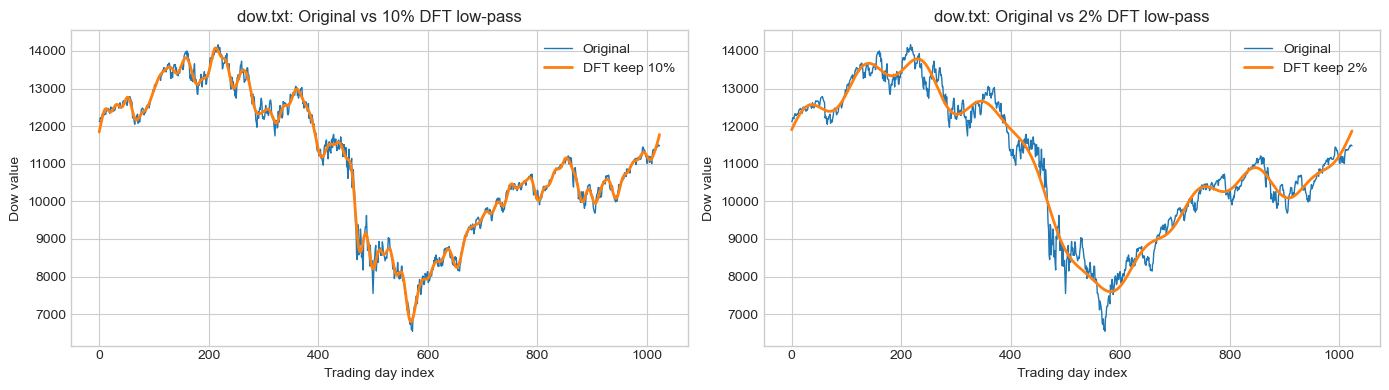

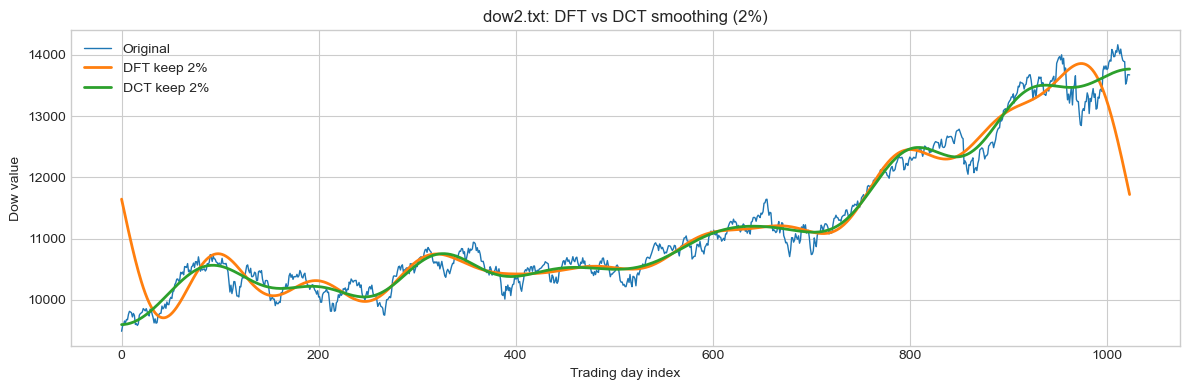

Comment:
- Keeping only low-frequency coefficients removes fast fluctuations (high-frequency components).
- The 2% case is smoother than 10%, but may lose short-term variations.
- For dow2.txt, DFT smoothing shows larger edge deviation due to periodic extension.
- DCT smoothing improves boundary behavior because it uses an even extension.


In [3]:
# Q2(a)-(g): Fourier filtering and DCT smoothing

def low_pass_fft(signal, keep_ratio):
    """Keep only the first keep_ratio of rFFT coefficients."""
    coeff = np.fft.rfft(signal)
    n_keep = max(1, int(np.ceil(keep_ratio * len(coeff))))
    coeff_filtered = np.zeros_like(coeff)
    coeff_filtered[:n_keep] = coeff[:n_keep]
    return np.fft.irfft(coeff_filtered, n=len(signal))


def dct_matrix_ortho(N):
    """Orthogonal DCT-II matrix C so that c = C @ x and x = C.T @ c."""
    n = np.arange(N)
    k = np.arange(N)[:, None]
    C = np.sqrt(2.0 / N) * np.cos(np.pi * (n + 0.5) * k / N)
    C[0, :] = np.sqrt(1.0 / N)
    return C


def dct_smooth(signal, keep_ratio):
    N = len(signal)
    C = dct_matrix_ortho(N)
    c = C @ signal
    n_keep = max(1, int(np.ceil(keep_ratio * N)))
    c_filtered = np.zeros_like(c)
    c_filtered[:n_keep] = c[:n_keep]
    reconstructed = C.T @ c_filtered
    return reconstructed

# dow.txt analysis

dow = np.loadtxt(dow_path)
days = np.arange(len(dow))
dow_10 = low_pass_fft(dow, 0.10)
dow_02 = low_pass_fft(dow, 0.02)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(days, dow, label='Original', linewidth=1)
axes[0].plot(days, dow_10, label='DFT keep 10%', linewidth=2)
axes[0].set_title('dow.txt: Original vs 10% DFT low-pass')
axes[0].set_xlabel('Trading day index')
axes[0].set_ylabel('Dow value')
axes[0].legend()

axes[1].plot(days, dow, label='Original', linewidth=1)
axes[1].plot(days, dow_02, label='DFT keep 2%', linewidth=2)
axes[1].set_title('dow.txt: Original vs 2% DFT low-pass')
axes[1].set_xlabel('Trading day index')
axes[1].set_ylabel('Dow value')
axes[1].legend()

plt.tight_layout()
plt.show()

# dow2.txt analysis: DFT vs DCT with 2%
dow2 = np.loadtxt(dow2_path)
days2 = np.arange(len(dow2))
dow2_dft_02 = low_pass_fft(dow2, 0.02)
dow2_dct_02 = dct_smooth(dow2, 0.02)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(days2, dow2, label='Original', linewidth=1)
ax.plot(days2, dow2_dft_02, label='DFT keep 2%', linewidth=2)
ax.plot(days2, dow2_dct_02, label='DCT keep 2%', linewidth=2)
ax.set_title('dow2.txt: DFT vs DCT smoothing (2%)')
ax.set_xlabel('Trading day index')
ax.set_ylabel('Dow value')
ax.legend()
plt.tight_layout()
plt.show()

print('Comment:')
print('- Keeping only low-frequency coefficients removes fast fluctuations (high-frequency components).')
print('- The 2% case is smoother than 10%, but may lose short-term variations.')
print('- For dow2.txt, DFT smoothing shows larger edge deviation due to periodic extension.')
print('- DCT smoothing improves boundary behavior because it uses an even extension.')

## 3) Image Deblurring

Read the blurred image, construct a periodic Gaussian point spread function (PSF) with $\sigma=25$, and perform deconvolution in Fourier space with threshold protection for tiny PSF coefficients.

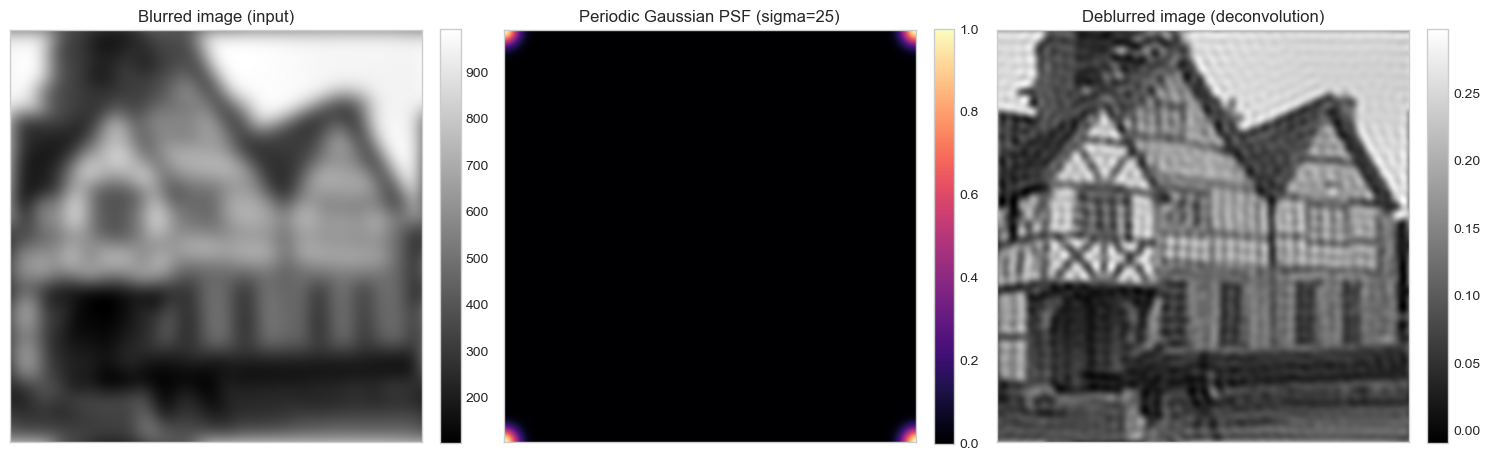

Image shape: (1024, 1024)
Number of protected Fourier coefficients (|PSF| < 0.001): 1044527
Comment: Deconvolution sharpens edges, while thresholding avoids numerical blow-up in near-zero PSF modes.


In [4]:
# Q3(a)(b)(c): Image deblurring
blurred = np.loadtxt(blur_path)
ny, nx = blurred.shape
sigma = 25.0

# Build periodic Gaussian PSF centered at the periodic origin
x = np.arange(nx)
y = np.arange(ny)
xx, yy = np.meshgrid(x, y)

# Periodic distance to origin: creates bright patches near all corners in visualization
x_wrap = np.minimum(xx, nx - xx)
y_wrap = np.minimum(yy, ny - yy)
psf = np.exp(-(x_wrap**2 + y_wrap**2) / (2 * sigma**2))

# Fourier deconvolution with thresholding
F_blur = np.fft.fft2(blurred)
F_psf = np.fft.fft2(psf)

threshold = 1e-3
small = np.abs(F_psf) < threshold

F_deblur = F_blur.copy()
F_deblur[~small] = F_blur[~small] / F_psf[~small]

# Keep unchanged where |F_psf| is too small to avoid instability
restored = np.fft.ifft2(F_deblur).real

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

im0 = axes[0].imshow(blurred, cmap='gray', origin='upper')
axes[0].set_title('Blurred image (input)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(psf, cmap='magma', origin='upper')
axes[1].set_title('Periodic Gaussian PSF (sigma=25)')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(restored, cmap='gray', origin='upper')
axes[2].set_title('Deblurred image (deconvolution)')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

print(f'Image shape: {blurred.shape}')
print(f'Number of protected Fourier coefficients (|PSF| < {threshold}): {small.sum()}')
print('Comment: Deconvolution sharpens edges, while thresholding avoids numerical blow-up in near-zero PSF modes.')

## 4) Solve the Poisson Equation by a Spectral Method

Solve
\[
\frac{\partial^2\phi}{\partial x^2}+\frac{\partial^2\phi}{\partial y^2}=\rho(x,y)
\]
on \(0\le x\le 1, 0\le y\le 2\), with spacing \(\Delta\le 0.01\), and boundary conditions:
- \(\phi(0,y)=0\), \(\phi(1,y)=0\)
- \(\phi(x,0)=0\), \(\phi(x,2)=\sqrt{1-x^2}\)

Use a 2D sine-series spectral solve on interior points. Nonzero boundary values are moved to the right-hand side of the interior discrete Poisson equation as boundary contributions, then the interior system is solved in DST space.

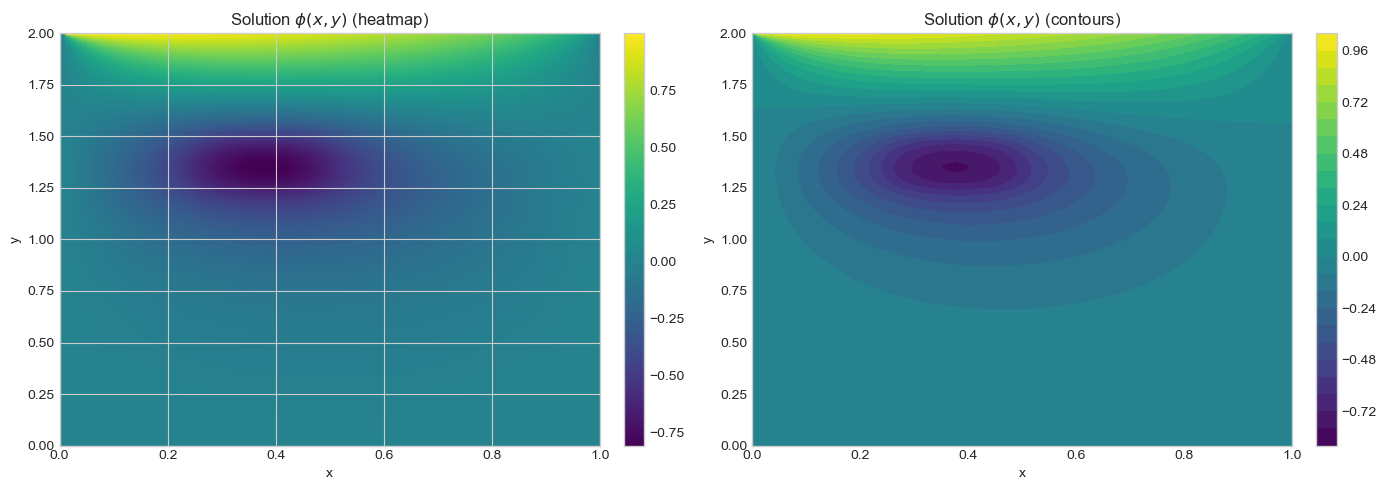

Grid spacing: 0.01 0.01
Grid shape: (101, 201)
phi min / max: -0.8085542965473109 0.9999499987499375
Max interior residual (abs): 1.787459069646502e-10
Comment: Potential is elevated near the top boundary and perturbed by the source block around x=[0.25,0.5), y=[1.25,1.5).


In [5]:
# Q4: Spectral solution (boundary contributions moved to RHS)

dx = 0.01
dy = 0.01
x = np.arange(0, 1 + dx, dx)
y = np.arange(0, 2 + dy, dy)
Nx = len(x)
Ny = len(y)

X, Y = np.meshgrid(x, y, indexing='ij')

# Source density rho(x,y)
rho = np.zeros((Nx, Ny))
mask = (X >= 0.25) & (X < 0.5) & (Y >= 1.25) & (Y < 1.5)
rho[mask] = 16 * np.pi

# Boundary values
phi_bc = np.zeros((Nx, Ny))
top_bc = np.sqrt(np.clip(1 - x**2, 0, None))
phi_bc[1:-1, -1] = top_bc[1:-1]
phi_bc[0, -1] = 0.0
phi_bc[-1, -1] = 0.0

# Interior RHS with boundary contributions
rhs_int = rho[1:-1, 1:-1].copy()
rhs_int[0, :] -= phi_bc[0, 1:-1] / dx**2
rhs_int[-1, :] -= phi_bc[-1, 1:-1] / dx**2
rhs_int[:, 0] -= phi_bc[1:-1, 0] / dy**2
rhs_int[:, -1] -= phi_bc[1:-1, -1] / dy**2

nx = rhs_int.shape[0]
ny = rhs_int.shape[1]


def dst1_matrix_ortho(n):
    i = np.arange(1, n + 1)[:, None]
    k = np.arange(1, n + 1)[None, :]
    S = np.sqrt(2.0 / (n + 1)) * np.sin(np.pi * i * k / (n + 1))
    return S

Sx = dst1_matrix_ortho(nx)
Sy = dst1_matrix_ortho(ny)

# Forward transform (orthonormal DST-I)
R_hat = Sx.T @ rhs_int @ Sy

# Eigenvalues of discrete Laplacian with zero Dirichlet boundaries
p = np.arange(1, nx + 1)
q = np.arange(1, ny + 1)
lambda_x = 2.0 * (np.cos(np.pi * p / (nx + 1)) - 1.0) / dx**2
lambda_y = 2.0 * (np.cos(np.pi * q / (ny + 1)) - 1.0) / dy**2
Lambda = lambda_x[:, None] + lambda_y[None, :]

Phi_hat = R_hat / Lambda

# Inverse transform for interior solution
phi_int = Sx @ Phi_hat @ Sy.T

phi = phi_bc.copy()
phi[1:-1, 1:-1] = phi_int

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(phi.T, origin='lower', extent=[0, 1, 0, 2], cmap='viridis', aspect='auto')
axes[0].set_title(r'Solution $\phi(x,y)$ (heatmap)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

cont = axes[1].contourf(X, Y, phi, levels=25, cmap='viridis')
axes[1].set_title(r'Solution $\phi(x,y)$ (contours)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.colorbar(cont, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Interior residual check for the finite-difference equation
lap_phi_int = (
    (phi[0:-2, 1:-1] - 2 * phi[1:-1, 1:-1] + phi[2:, 1:-1]) / dx**2
    + (phi[1:-1, 0:-2] - 2 * phi[1:-1, 1:-1] + phi[1:-1, 2:]) / dy**2
)
residual = lap_phi_int - rho[1:-1, 1:-1]

print('Grid spacing:', dx, dy)
print('Grid shape:', phi.shape)
print('phi min / max:', float(phi.min()), float(phi.max()))
print('Max interior residual (abs):', float(np.max(np.abs(residual))))
print('Comment: Potential is elevated near the top boundary and perturbed by the source block around x=[0.25,0.5), y=[1.25,1.5).')